# Who Earned the Credit?

> *Splitting a channel's Media-Mix impact across campaigns — using a 100-year-old idea from insurance*

Your Media-Mix Model has done its job. It tells you, with honest uncertainty,
that **Paid Social drove this much incremental revenue** — day by day. You bring
it to the review, and the first question is the one the MMM can't answer:

> *"Great — but **which campaign**?"*

So you open the platform dashboard. Every campaign is proudly claiming
conversions. Add them up and they total far more than the MMM says the whole
channel earned. The always-on brand campaign looks steady; a flashy weekend
burst looks like a superstar; a tiny niche campaign swings from hero to flop
week to week; and the broad prospecting push that only launched in April has
barely four weeks of history to its name. And you already know the dirty
secret: most of those "conversions" are rule-based and **non-incremental** —
plenty of those people would have converted anyway.

Strip the noise away and the problem is simple. You have **one number you
trust** (the MMM's channel total) and **seven shaky signals** (the per-campaign
platform numbers). The question is not *whether* to use the shaky signals —
they're all you have — it's **how much to believe each one**.

::: {.callout-tip title="The old idea we're going to borrow"}
This is *exactly* the problem an insurance actuary solves before breakfast.

Picture pricing car insurance. A driver comes in with **one** claim-free year.
Do you give them the flawless-driver discount? Of course not — one year is too
little to tell skill from luck. So you **blend** their record with the average
driver, and you lean on their own history *more and more as it piles up*:

$$\text{best guess}=Z\cdot(\text{their record})+(1-Z)\cdot(\text{average driver}),
\qquad Z=\frac{n}{n+k}.$$

That blend has a name — **credibility** — and a single dial, **Z**, that runs
from 0 ("I'll trust the average") to 1 ("I'll trust you"). It turns on one thing:
**how much evidence you have** ($n$), measured against a threshold $k$ that says
how much evidence counts as "enough."

The arithmetic is friendly. Say $k$ works out to 20,000 reached people. A
campaign that reached 60,000 gets $Z=\tfrac{60}{60+20}=0.75$ — we believe 75% of
its own story and fill the rest with the group average. A campaign that reached
8,000 gets $Z=\tfrac{8}{8+20}\approx 0.29$ — mostly the average, until it earns
more trust. Nobody is ignored; nobody is blindly believed.
:::

**The whole idea of this notebook, in one sentence:** swap *"years of driving
history"* for *"how many people the campaign reached,"* and use that dial to
decide how much of each campaign's own story to believe. **Reach is evidence.**
Everything below is just that idea, done carefully and with honest uncertainty.

What you get at the end is worth the trip: a per-campaign, per-day split of the
MMM's channel credit that (a) always adds back up to the MMM total, (b) can't be
hijacked by small, loud campaigns, and (c) carries an honest uncertainty band
you can defend in the budget meeting — from a model short enough to read over
coffee.

::: {.callout-note collapse="true" title="For the statistically minded: the exact mapping (and why it equals Fay–Herriot)"}
This is **Bühlmann credibility**, which blends a policyholder's own experience
with the collective mean,
$$\text{premium}=Z\cdot(\text{own})+(1-Z)\cdot(\text{collective}),\qquad Z=\frac{n}{n+k},$$
and it is *exactly* hierarchical-Bayes partial pooling.

| Bühlmann credibility (actuarial) | This MMM disaggregation |
|---|---|
| Policyholder | Campaign $c$ |
| Portfolio / *collective* | The whole social channel |
| Own loss experience (noisy) | Naive contribution-per-reached-user (social split by click share) |
| Exposure / sample size $n$ | **Reach** $n_c$ — the effective sample size |
| Collective mean | Channel-average log-effectiveness $\mu$ |
| Credibility factor $Z_c=\frac{n_c}{n_c+k}$ | Trust in a campaign's own signal |
| Credibility premium | Shrunk per-campaign log-effectiveness $\theta_c$ |

Writing the direct estimate's sampling variance as $\psi_c=s^2/n_c$,
$$Z_c=\frac{n_c}{n_c+k}=\frac{\tau^2}{\tau^2+\psi_c}=1-B_c^{\text{FH}},$$
so this is the **actuarial twin of the Fay–Herriot notebook** — but with sampling
variances *derived from reach* rather than assumed.
:::

In [1]:
import warnings

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import xarray as xr
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
az.style.use("arviz-vibrant")
plt.rcParams["figure.figsize"] = [7.6, 6.0]  # hidden default — every plot inherits this
plt.rcParams["figure.dpi"] = 100
%config InlineBackend.figure_format = "retina"

## Meet the seven campaigns

Seven campaigns ran on one social channel across a 120-day window — six
veterans plus a broad prospecting push that only kicked off April 1st. We load
the everyday
delivery telemetry any analyst has (spend, impressions, reach, clicks), plus the
**MMM's social-contribution posterior** — the full range of plausible values for
the channel's daily impact, not just a point estimate. That's the trustworthy
number we're going to divide up. We also quietly load a simulated ground truth,
used **only** at the very end to grade our work, never to fit.

In [2]:
from pathlib import Path

_DEV = Path("docs/source/notebooks/mmm/dev/data")
DATA = Path("data") if (Path("data") / "campaign_daily_metrics.csv").exists() else _DEV
metrics = pd.read_csv(DATA / "campaign_daily_metrics.csv", parse_dates=["date"])
cum_reach = pd.read_csv(
    DATA / "campaign_cumulative_reach.csv", index_col=0, parse_dates=True
)
overlap = pd.read_csv(DATA / "audience_overlap_matrix.csv", index_col=0)
mmm_df = pd.read_csv(DATA / "mmm_input_data.csv", parse_dates=["date"])
contrib = xr.open_dataset(DATA / "channel_contribution_posterior.nc")[
    "channel_contribution"
]
social = contrib.sel(channel="social")
CAMPAIGNS = list(cum_reach.columns)
truth = pd.read_csv(
    DATA / "ground_truth_campaign_contributions.csv", index_col=0, parse_dates=True
)  # ORACLE: validation only

Two things are worth a look before we start: **how big each campaign is** — its
reach, the evidence it carries into the analysis — and **the channel total the
MMM hands us**, the number we're going to divide up.

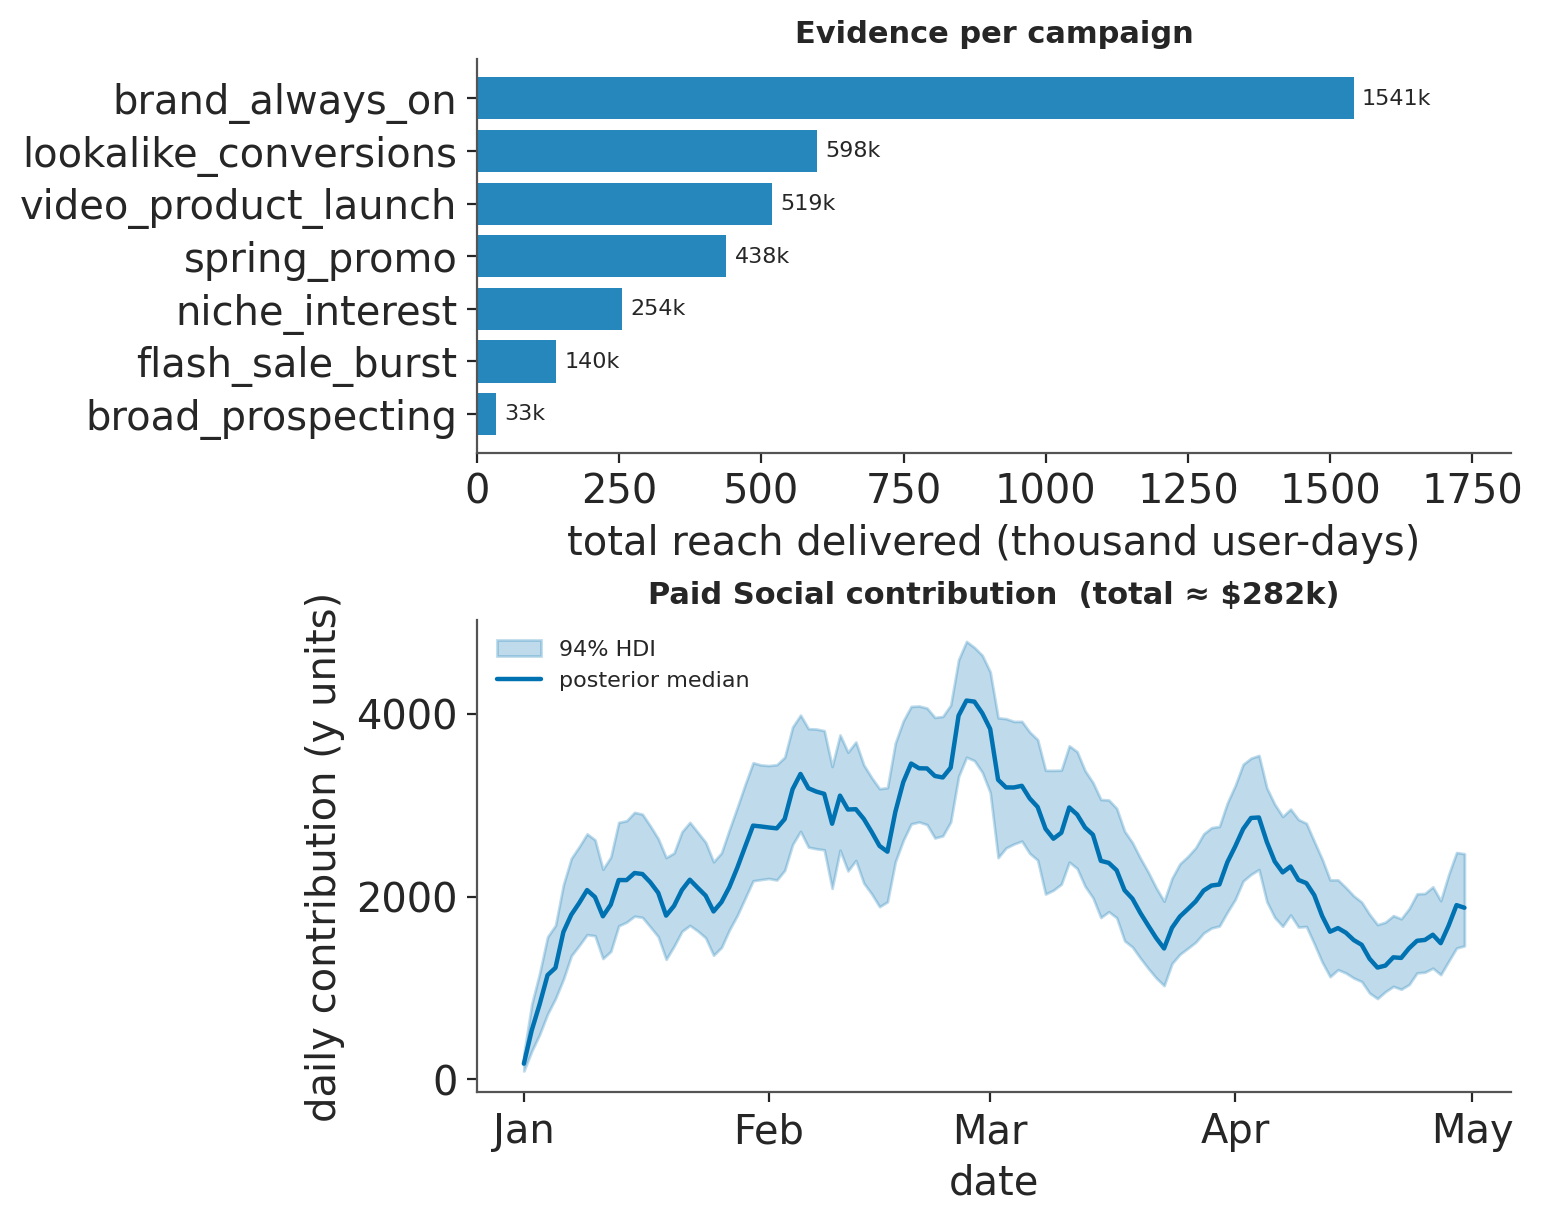

In [3]:
import matplotlib.dates as mdates

reach_tot = metrics.groupby("campaign")["reach"].sum().reindex(CAMPAIGNS).sort_values()

soc_s = social.stack(sample=("chain", "draw"))
soc_dates = mmm_df["date"]
soc_med = soc_s.median("sample").to_numpy()
soc_hdi = az.hdi(soc_s, dim="sample", prob=0.94)
soc_lo = soc_hdi.sel(ci_bound="lower").to_numpy()
soc_hi = soc_hdi.sel(ci_bound="upper").to_numpy()
total_mean = float(social.sum("date").mean())

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, gridspec_kw={"height_ratios": [1.0, 1.2]}, layout="constrained"
)

bars = ax_top.barh(
    reach_tot.index, reach_tot.to_numpy() / 1e3, color="#0072b2", alpha=0.85
)
ax_top.bar_label(bars, fmt="%.0fk", padding=3, fontsize=8)
ax_top.set_title("Evidence per campaign", fontsize=11)
ax_top.set_xlabel("total reach delivered (thousand user-days)")
ax_top.margins(x=0.18)

ax_bot.fill_between(
    soc_dates, soc_lo, soc_hi, color="#0072b2", alpha=0.25, label="94% HDI"
)
ax_bot.plot(soc_dates, soc_med, color="#0072b2", lw=1.6, label="posterior median")
ax_bot.set_title(
    f"Paid Social contribution  (total ≈ ${total_mean / 1e3:,.0f}k)", fontsize=11
)
ax_bot.set_xlabel("date")
ax_bot.set_ylabel("daily contribution (y units)")
ax_bot.xaxis.set_major_locator(mdates.MonthLocator())
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax_bot.legend(loc="upper left", fontsize=8);

> **Fig.** Top: how much *evidence* each campaign carries — its total reach delivered, summed across the flight, which is the effective sample size that sets its trust dial. The April-born broad_prospecting carries the least (it has only been live for 30 days), followed by the 15-day flash_sale_burst; the always-on brand the most. Bottom: what the MMM hands us — Paid Social's daily incremental contribution with its 94% credible interval; the ≈ $282k area under it is the number we split across campaigns.

## How noisy is each campaign, really?

To turn the dial we need two things per campaign: **how much evidence it has**
(its total reach), and **its own noisy story** (a rough guess at how much revenue
it drove per person it reached). Both come from data — so let's be concrete about
what you already have, and what you'll have to build.

### The data you already have

Every ad platform, and its reporting API, hands you a table like this — one row
per campaign per day, with delivery, attention, and cost:

In [4]:
platform_export = (
    metrics.loc[
        metrics["impressions"] > 0,
        ["date", "campaign", "reach", "impressions", "clicks", "spend"],
    ]
    .assign(
        ctr_imp_pct=lambda d: (100 * d["clicks"] / d["impressions"]).round(2),
        cpm=lambda d: (1000 * d["spend"] / d["impressions"]).round(2),
    )
    .drop(columns="spend")
    .rename(columns={"ctr_imp_pct": "ctr_imp_%", "cpm": "cpm"})
)
# one mid-flight day in February, when six of the seven campaigns are live
# (broad_prospecting doesn't launch until April), to show the columns
_day = sorted(metrics["date"].unique())[55]
platform_export[platform_export["date"] == _day].reset_index(drop=True)

,date,campaign,reach,impressions,clicks,ctr_imp_%,cpm
0,2025-02-25,brand_always_on,13911,26919,408,1.52,13.43
1,2025-02-25,spring_promo,9437,18430,371,2.01,15.00
2,2025-02-25,lookalike_conversions,3386,4006,70,1.75,17.13
3,2025-02-25,video_product_launch,7426,14472,150,1.04,10.43
4,2025-02-25,flash_sale_burst,11227,41245,769,1.86,15.30
5,2025-02-25,niche_interest,1859,2342,52,2.22,19.26


This is genuinely useful — **exposure** (reach, impressions), **attention**
(clicks and the impression-based click-through rate), and **cost** (CPM). It's
also all most teams ever look at. But for *our* question — who deserves the
channel's credit — it has two blind spots:

- **Its `reach` is duplicated across days.** Each day's number counts everyone the
  campaign touched *that day*; the same person reappears tomorrow. Sum the column
  and you get impressions-flavoured *volume*, not how many real people you
  reached — so it can't tell you when a campaign has **saturated its audience**
  (the point where more spend just re-hits the same faces).
- **It says nothing about overlap.** Two campaigns can spend on largely the *same*
  people; this table shows them as independent. Ignore that and any per-campaign
  credit double-counts the shared audience.

Unduplicated audience growth and cross-campaign overlap are the signals this
analysis runs on — and neither is a column you can export directly. The good
news: you can build both from the *same* platform/API, with a particular **query
pattern** and no extra tracking.

### The data you need — and how to build it

**1 · Unduplicated reach growth — the "expanding window."** Don't pull one report
of daily reach. Pull a *series* of reports where you fix the start date and push
the **end** date out one day at a time: `[start → day 0]`, then `[start → day 1]`,
then `[start → day 2]`, … through `[start → day N]`. The platform de-duplicates
*within* each report, so each one is the true unique reach so far, and the
**difference between consecutive reports is the count of genuinely new people**
reached that day. Stitch them together and you get a clean, C-shaped
audience-growth curve instead of a duplicated daily count:

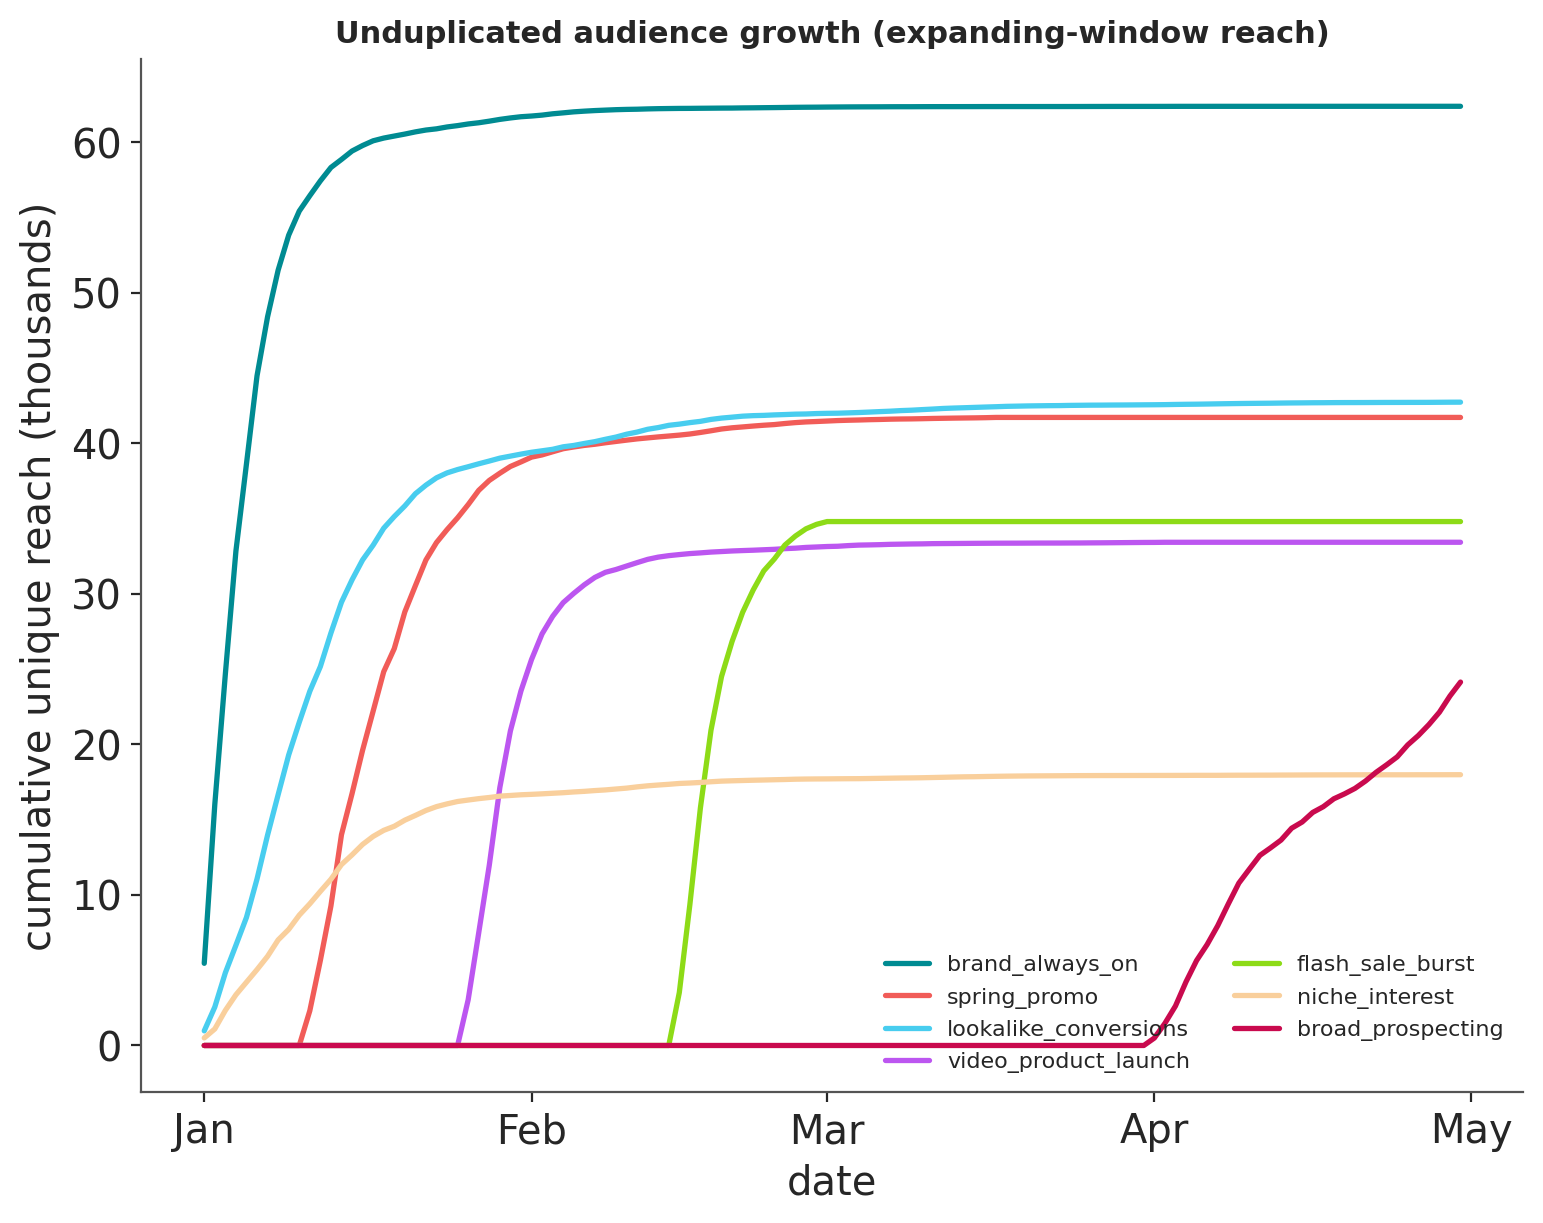

In [5]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(layout="constrained")
for c in CAMPAIGNS:
    ax.plot(cum_reach.index, cum_reach[c] / 1e3, lw=1.9, label=c)
ax.set_title("Unduplicated audience growth (expanding-window reach)", fontsize=11)
ax.set_xlabel("date")
ax.set_ylabel("cumulative unique reach (thousands)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(fontsize=8, ncol=2);

> **Fig.** The expanding-window result: cumulative unique reach per campaign. Most curves are C-shaped — steep while the campaign keeps finding new people, then flattening as it exhausts its audience — and that flattening point is the audience saturation the raw daily table can't reveal. Scales differ enormously (brand_always_on saturates near 62k unique users, niche_interest near 18k). The one exception is broad_prospecting: it launched April 1st against a very large audience and is still climbing when the window closes — no saturation knee, just a left-censored growth curve.

**2 · Campaign overlap — pairwise inclusion–exclusion.** The same multi-report
trick, asked of campaign *groups*. For each pair, pull reach for A alone, for B
alone, and for the combined A∪B group; the shared audience is then

$$\text{overlap}(A, B) = \text{Reach}(A) + \text{Reach}(B) - \text{Reach}(A \cup B).$$

Repeat over the pairs (and larger groups) you care about to fill an N×N matrix.
Its diagonal is each campaign's own audience size; the off-diagonals are shared
users (zero where targeting is disjoint):

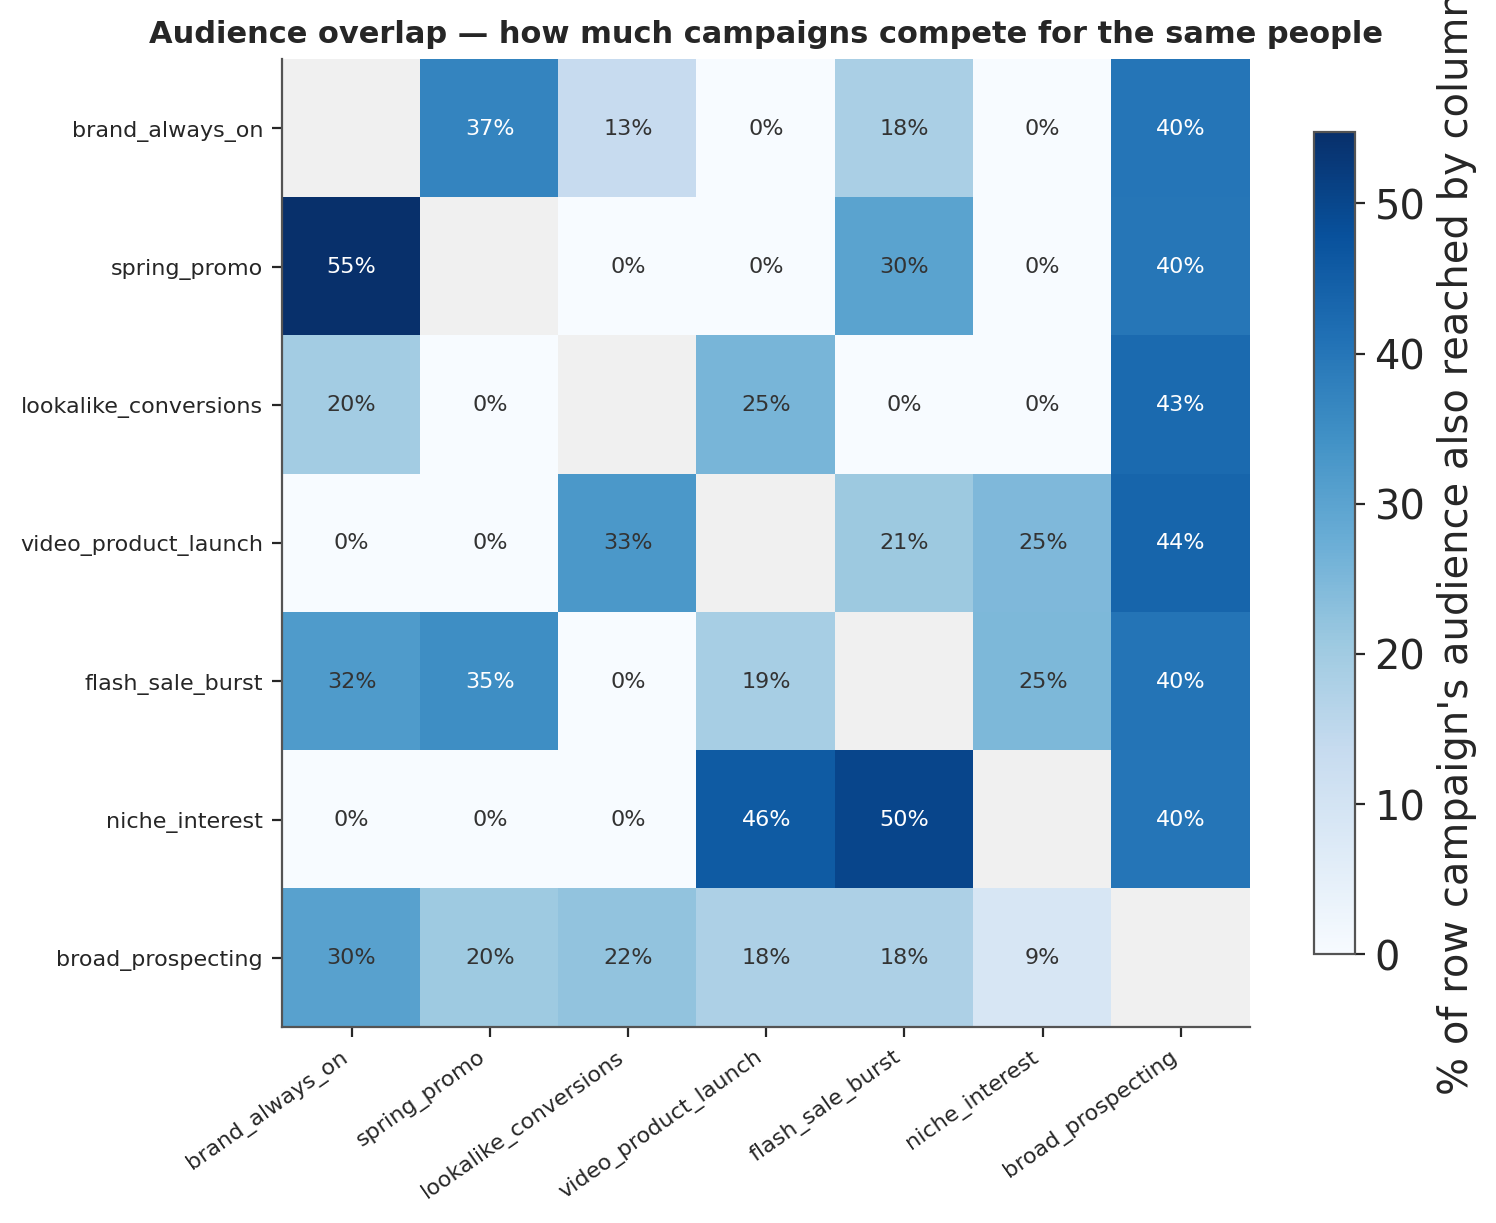

In [6]:
ov = overlap.reindex(index=CAMPAIGNS, columns=CAMPAIGNS).to_numpy(dtype=float)
frac = 100 * ov / np.diag(ov)[:, None]  # % of row campaign's audience also in column
np.fill_diagonal(frac, np.nan)  # the diagonal is trivially 100%
masked = np.ma.masked_invalid(frac)

fig, ax = plt.subplots(layout="constrained")
cmap = plt.get_cmap("Blues").copy()
cmap.set_bad("#f0f0f0")
hi = float(np.nanmax(frac))
im = ax.imshow(masked, cmap=cmap, vmin=0, vmax=hi)
ax.set_xticks(range(len(CAMPAIGNS)))
ax.set_xticklabels(CAMPAIGNS, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(CAMPAIGNS)))
ax.set_yticklabels(CAMPAIGNS, fontsize=8)
for i in range(len(CAMPAIGNS)):
    for j in range(len(CAMPAIGNS)):
        v = frac[i, j]
        if not np.isnan(v):
            ax.text(
                j,
                i,
                f"{v:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if v > 0.6 * hi else "#333333",
            )
ax.set_title(
    "Audience overlap — how much campaigns compete for the same people", fontsize=11
)
fig.colorbar(
    im, ax=ax, shrink=0.85, label="% of row campaign's audience also reached by column"
)

> **Fig.** Audience overlap from the pairwise reach queries. Read each row as: of that campaign's audience, what share is also reached by the campaign in each column. Bright cells are contested audiences (more than half of spring_promo's audience is also hit by brand_always_on); grey cells are disjoint targeting. This is the competition structure inside your own account.

This notebook only needs the **reach** signal (technique 1); the overlap matrix
(technique 2) isn't used below, but it's what lets you understand the
**competition inside your own system** — how much your campaigns are fighting
over the same people. We loaded both up front so you can see the shape of each.

### The noisy "own story"

For that own story we do something deliberately crude — exactly the kind of
back-of-envelope split a platform dashboard invites. We take the MMM's total
social credit, hand it out in proportion to each campaign's **clicks**, and
express the result *per reached user*. It's noisy and non-incremental on
purpose: it's the shaky signal we're trying to discipline, not trust. (We'll
work with the **log** of that rate, so "twice as effective" is the same size
step whether a campaign is weak or strong — the natural scale for comparing
rates.)

In [7]:
from scipy.stats import spearmanr

agg = (
    metrics.groupby("campaign")
    .agg(
        reach=("reach", "sum"), clicks=("clicks", "sum"), active_days=("active", "sum")
    )
    .reindex(CAMPAIGNS)
)
n_reach = agg["reach"].to_numpy(dtype=float)  # effective sample size n_c
clicks = agg["clicks"].to_numpy(dtype=float)
n_rel = n_reach / n_reach.mean()  # relative exposure (keeps s^2 ~ O(1))

theta_total_mean = float(social.sum("date").mean())  # trusted MMM input (level)
naive_share_clicks = clicks / clicks.sum()  # crude non-incremental split
naive_rate = (
    theta_total_mean * naive_share_clicks / n_reach
)  # contribution per reached user
y_direct = np.log(naive_rate)  # log rate = the direct estimate

direct = pd.DataFrame(
    {
        "reach_n": n_reach.astype(int),
        "clicks": clicks.astype(int),
        "active_days": agg["active_days"].astype(int).to_numpy(),
        "naive_clicks_share": naive_share_clicks,
        "naive_rate": naive_rate,
        "y_direct": y_direct,
    },
    index=CAMPAIGNS,
).sort_values("reach_n", ascending=False)
direct.round(4)

,reach_n,clicks,active_days,naive_clicks_share,naive_rate,y_direct
brand_always_on,1541137,40073,120,0.3903,0.0714,-2.6399
lookalike_conversions,597676,16891,120,0.1645,0.0776,-2.5566
video_product_launch,519340,10628,71,0.1035,0.0562,-2.8794
spring_promo,438462,15985,66,0.1557,0.1001,-2.3020
niche_interest,254475,7709,120,0.0751,0.0831,-2.4872
flash_sale_burst,139620,10084,15,0.0982,0.1982,-1.6183
broad_prospecting,32921,1294,30,0.0126,0.1079,-2.2267


The picture below is the heart of the problem: each campaign's own noisy story,
laid against how much evidence it carries. The error bars get **wider the fewer
people a campaign reached** — less evidence, more uncertainty.

Keep your eye on two campaigns. **`flash_sale_burst`** — a short, splashy
weekend campaign — is sitting *way* above the average. It looks like a
superstar. And **`broad_prospecting`**, the April newcomer, also reads
above-average — but with barely 30 days of delivery it carries the **least
evidence of all**, so its error bar is the widest on the chart. Are either of
them really that good? Hold that thought.

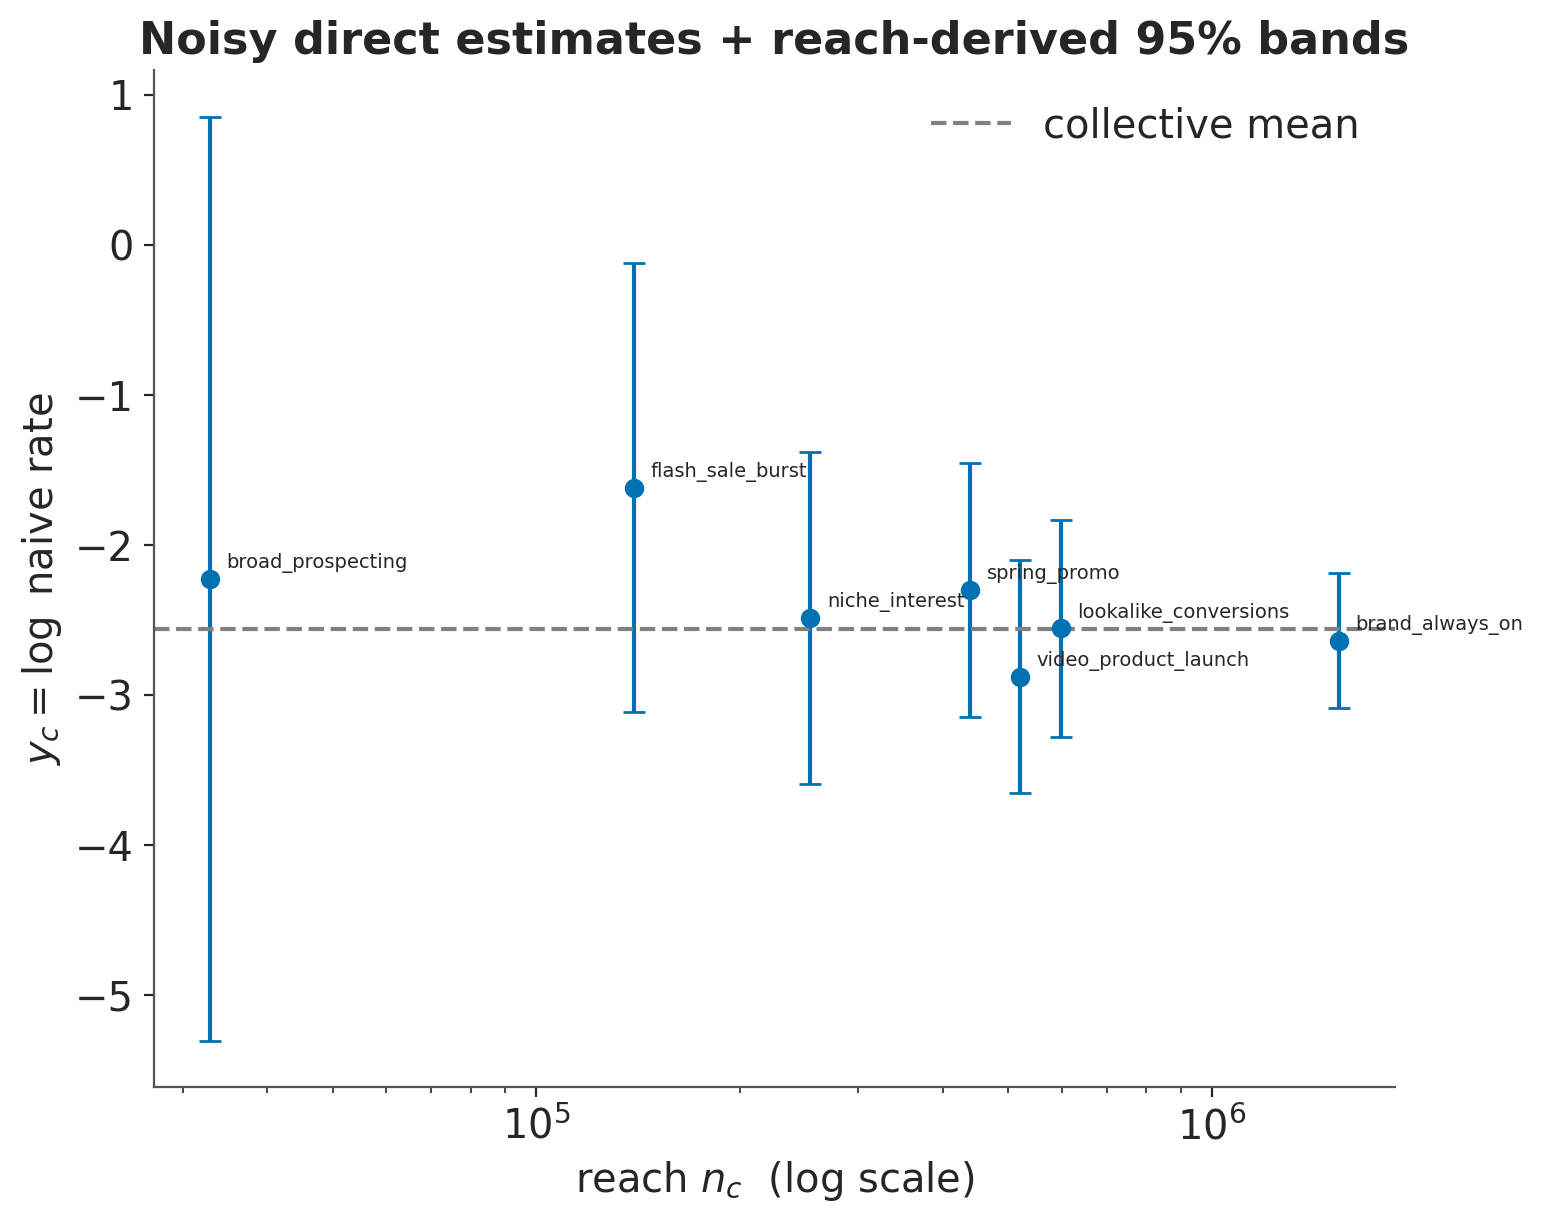

In [8]:
s2_illus = float(np.var(y_direct, ddof=1))  # plug-in dispersion for the picture only
se_illus = np.sqrt(s2_illus / n_rel)  # reach-derived SE ~ 1/sqrt(reach)
mu_illus = float(np.average(y_direct, weights=n_reach))

order = np.argsort(n_reach)
fig, ax = plt.subplots(layout="constrained")
ax.errorbar(
    n_reach[order],
    y_direct[order],
    yerr=1.96 * se_illus[order],
    fmt="o",
    capsize=4,
    color="#0072b2",
)
ax.axhline(mu_illus, ls="--", color="gray", label="collective mean")
for i in order:
    ax.annotate(
        CAMPAIGNS[i],
        (n_reach[i], y_direct[i]),
        fontsize=7,
        xytext=(6, 4),
        textcoords="offset points",
    )
ax.set(
    xscale="log",
    title="Noisy direct estimates + reach-derived 95% bands",
    xlabel="reach $n_c$  (log scale)",
    ylabel="$y_c=\\log$ naive rate",
)
ax.legend();

> **Fig.** Each campaign's noisy own-story plotted against its evidence (reach, log scale). Small-reach campaigns carry the widest bands: the 30-day-old broad_prospecting has the least evidence and the biggest error bar of all, and flash_sale_burst sits far above the collective mean — both prime shrinkage targets.

## Turning the dial

Now we let the data set the dial for us. Instead of decreeing "a campaign is
only half-trusted until it reaches 50k people," or handing everyone a flat
`Z = 0.5` by gut, we write the blend down as a small model and let it learn —
alongside the channel average itself — the **two numbers that set the dial**,
estimated from the seven campaigns together:

- **How much campaigns genuinely differ** from one another ($\tau$). If
  campaigns are basically alike, the group average is very informative and
  everyone gets pulled toward it hard.
- **How noisy one campaign's own signal is** for a given amount of reach
  ($s^2$). The noisier the signal, the more reach it takes to earn trust.

Their ratio *is* the evidence threshold ($k = s^2/\tau^2$), and each campaign's
dial follows automatically: $Z_c = n_c/(n_c+k)$. And because we fit this as a
Bayesian model, we don't get a single Z per campaign — we get a distribution.
Even the trust carries an error bar.

::: {.callout-note title="You're already setting Z — you just don't call it that"}
Every day-to-day call about campaign performance is a Z in disguise, set by gut:

- **Reading the dashboard at face value is `Z = 1`.** "This campaign shows 8× ROAS,
  that one 2× — move the budget" trusts each number fully, no matter how few people
  it reached. It's why small campaigns swing between hero and flop week to week.
- **Splitting by spend, or evenly, is `Z = 0`.** You've thrown away each campaign's
  own signal and leaned entirely on the average.
- **"Wait for enough conversions before you trust the CPA" is choosing `k`** — the
  evidence threshold where belief kicks in. (Meta and Google do exactly this with
  their campaign *learning phase*.)
- **"That 12× looks too good — tiny audience, call it maybe 4×" is a blend.** That's
  credibility done in your head: an unspoken Z somewhere between 0 and 1.

You can't *not* pick a Z. The only question is whether it's an arbitrary gut call
that shifts by analyst and by mood — or **one value estimated from how your
campaigns actually behave**, with its uncertainty attached. That is all the model
below does.
:::

The model below is short, and it is the entire method. Everything before it was
preparing its two inputs; everything after it is presentation.

In [9]:
coords = {"campaign": CAMPAIGNS}
with pm.Model(coords=coords) as credibility_model:
    reach_rel = pm.Data("reach_rel", n_rel, dims="campaign")
    mu = pm.Normal("mu", mu=float(y_direct.mean()), sigma=1.0)  # collective mean
    tau = pm.HalfNormal("tau", 0.4)  # sqrt(VHM)
    s2 = pm.HalfNormal("s2", 0.4)  # EPV per unit exposure
    psi = pm.Deterministic(
        "psi", s2 / reach_rel, dims="campaign"
    )  # reach-derived sampling variance
    Z = pm.Deterministic(
        "Z", tau**2 / (tau**2 + psi), dims="campaign"
    )  # Buhlmann credibility factor
    theta_raw = pm.Normal("theta_raw", 0.0, 1.0, dims="campaign")
    theta = pm.Deterministic(
        "theta", mu + tau * theta_raw, dims="campaign"
    )  # credible log-effectiveness
    pm.Normal(
        "y_obs", mu=theta, sigma=pm.math.sqrt(psi), observed=y_direct, dims="campaign"
    )

    idata = pm.sample(
        draws=1000, tune=2000, chains=2, cores=1, target_accept=0.995, random_seed=42
    )

n_div = int(idata.sample_stats["diverging"].sum())
rhat_max = float(az.summary(idata, var_names=["mu", "tau", "s2"])["r_hat"].max())
display(
    Markdown(f"**{n_div} divergences** · max $\\hat R$ (μ, τ, s²) = **{rhat_max:.3f}**")
)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [mu, tau, s2, theta_raw]


Sampling 2 chains for 2_000 tune and 1_000 draw iterations (4_000 + 2_000 draws total) took 5 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics


**1 divergences** · max $\hat R$ (μ, τ, s²) = **1.000**

Reading it line by line: `mu` is the channel-average effectiveness every
campaign is judged against; `tau` is how much campaigns truly differ; `psi`
(`s2 / reach`) is each campaign's noise — more reach, less noise; `Z` is the
trust dial that falls out of those two; and `theta` is each campaign's
trust-adjusted effectiveness — the blend of its own story and the group average.
Seven campaigns, five lines of structure. The sampler does the rest.

Here is each campaign's trust-adjusted effectiveness, with its uncertainty. The
big, well-measured campaigns speak for themselves; the small ones are quietly
reined in.

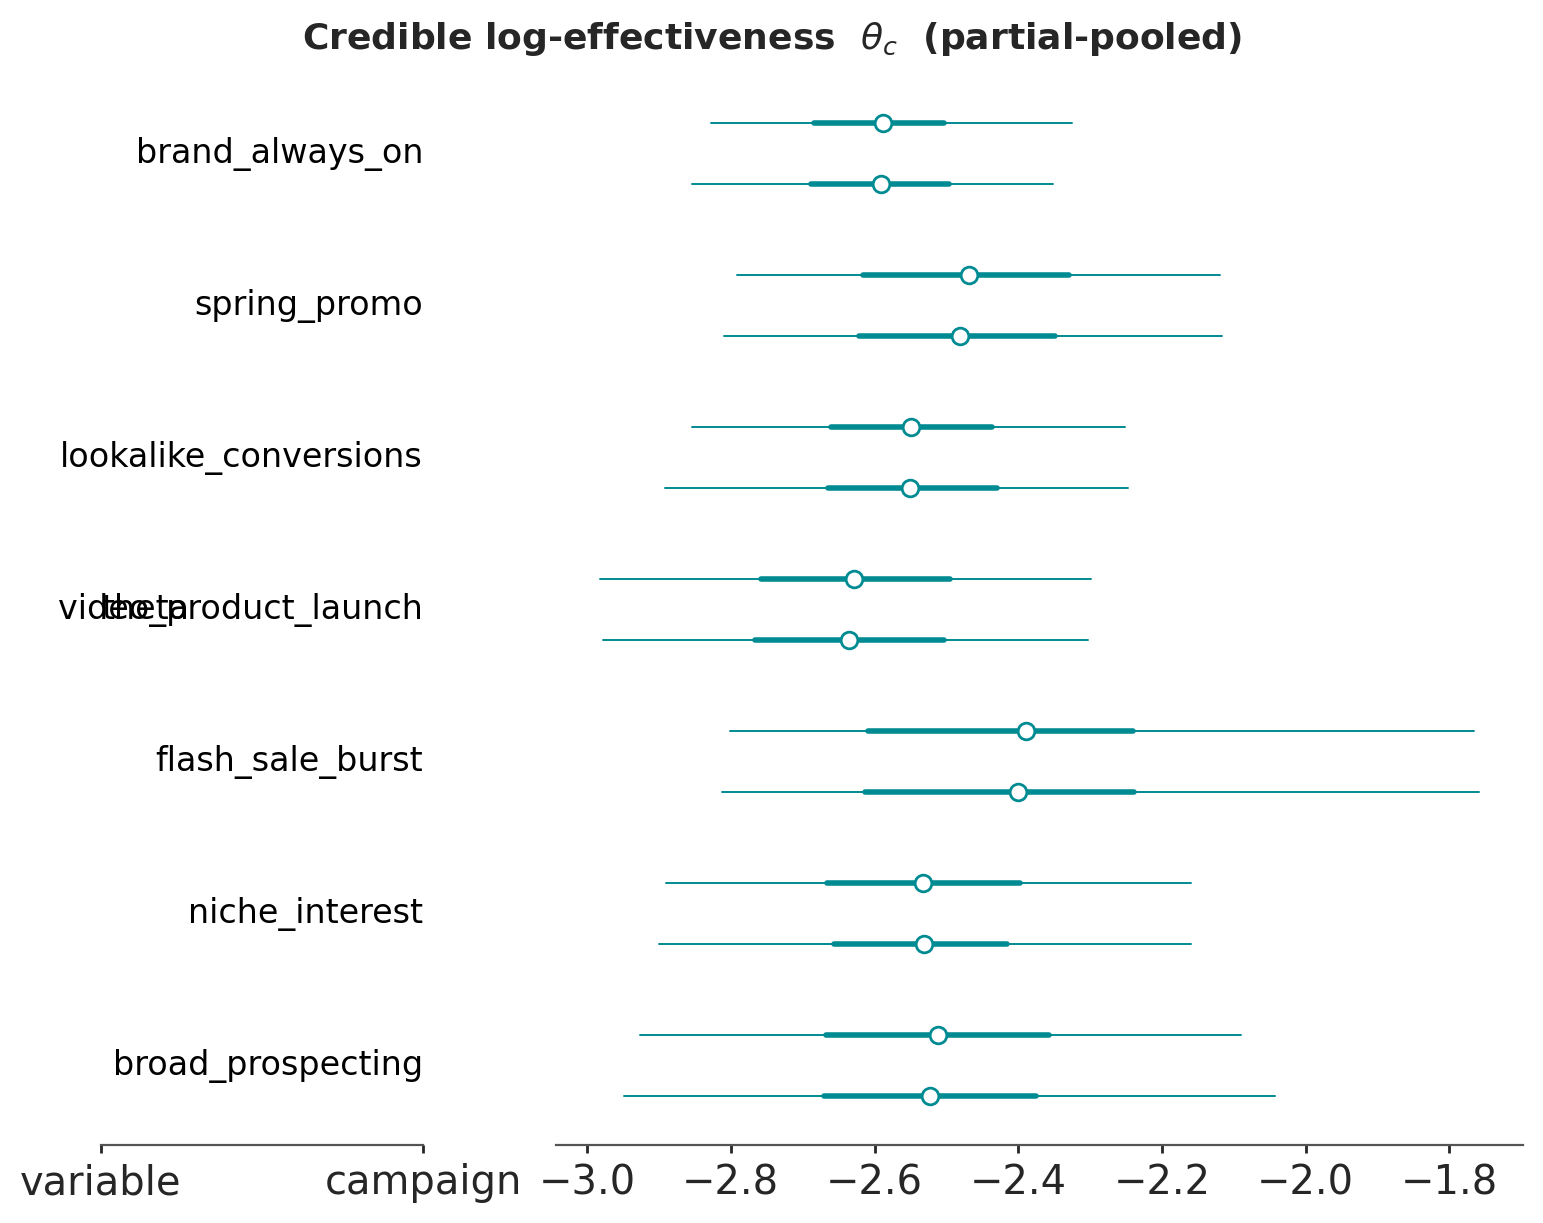

In [10]:
azp.plot_forest(idata, var_names=["theta"], figure_kwargs={"figsize": (7.6, 6.0)})
plt.gcf().suptitle(
    "Credible log-effectiveness  $\\theta_c$  (partial-pooled)", fontsize=13
);

> **Fig.** Trust-adjusted (partial-pooled) effectiveness per campaign, with uncertainty.

## Watch the superstar fall back to earth

This is the payoff picture. Each orange dot is a campaign's **naive** self-report;
each arrow shows where the model **moved** it after weighing the evidence. The
number under each campaign is its trust dial **Z** — and the campaigns are sorted
by reach, smallest on the left.

Notice the pattern: the small-reach campaigns on the left (lowest Z) get yanked
hard toward the channel average, while the big steady campaigns on the right
barely budge — they've earned their trust. And there's our "superstar":
**`flash_sale_burst`**, the tiny weekend burst whose novelty inflated its clicks,
gets pulled sharply back toward reality. That's the model refusing to be fooled
by a small, loud campaign.

Leftmost of all sits **`broad_prospecting`** — the April kickoff that is still
growing and hasn't come close to saturating its audience. Its own story reads
above-average, but 30 days of delivery is the least evidence on the board, so
it gets the lowest Z and the strongest pull toward the mean. That's not
punishment; it's patience — the model saying *"come back with more history and
I'll believe more of it."* As its reach curve keeps climbing, its Z will climb
with it, automatically.

This is the chart that changes the budget conversation. Trust the dashboard and
you'd scale `flash_sale_burst` next quarter; the trust-adjusted view says its
superstar week was mostly novelty plus small-sample luck. The same discipline
works in reverse, too — it protects a big, steady campaign from being punished
for one unlucky week.

Credibility constant $k \approx$ **1,110,923** (raw reach units); collective rate $e^\mu \approx$ **0.0795**.

,reach_n,Z_credibility,naive_rate,credible_rate,collective_rate
broad_prospecting,32921,0.0593,0.1079,0.0807,0.0795
flash_sale_burst,139620,0.1477,0.1982,0.0912,0.0795
niche_interest,254475,0.2036,0.0831,0.0795,0.0795
spring_promo,438462,0.2638,0.1001,0.0842,0.0795
video_product_launch,519340,0.2841,0.0562,0.0719,0.0795
lookalike_conversions,597676,0.3016,0.0776,0.0781,0.0795
brand_always_on,1541137,0.4277,0.0714,0.0750,0.0795


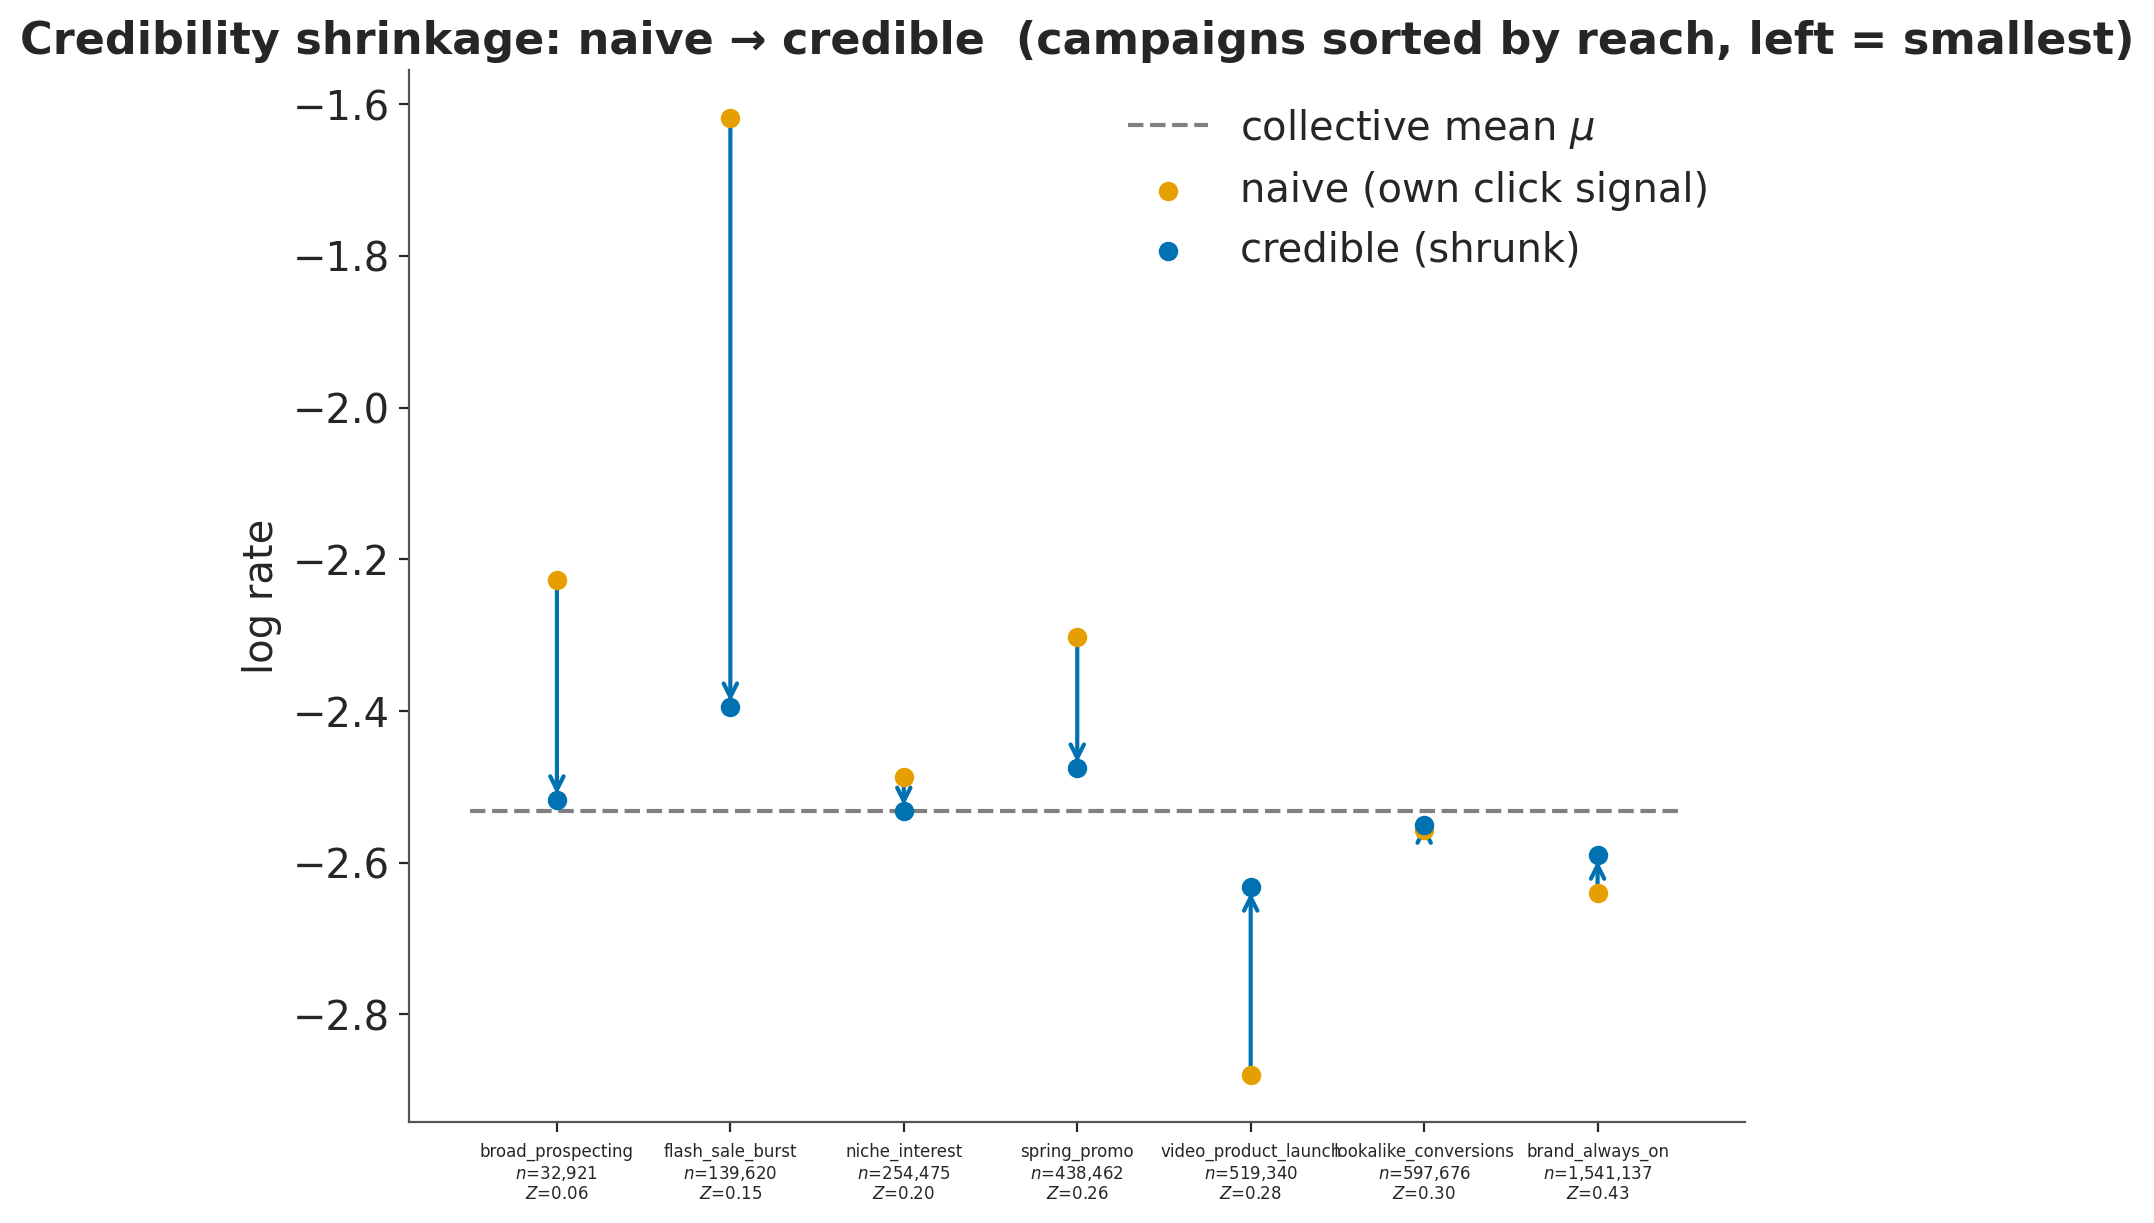

In [11]:
post = idata.posterior
Z_mean = post["Z"].mean(("chain", "draw")).to_pandas().reindex(CAMPAIGNS)
theta_mean = post["theta"].mean(("chain", "draw")).to_pandas().reindex(CAMPAIGNS)
mu_mean = float(post["mu"].mean())
# credibility constant k = s^2/tau^2 (structural plug-in), rescaled to raw-reach units
k_raw = float(post["s2"].mean()) / float((post["tau"] ** 2).mean()) * n_reach.mean()

shrink = pd.DataFrame(
    {
        "reach_n": n_reach.astype(int),
        "Z_credibility": Z_mean.to_numpy(),
        "naive_rate": np.exp(y_direct),
        "credible_rate": np.exp(theta_mean.to_numpy()),
        "collective_rate": np.exp(mu_mean),
    },
    index=CAMPAIGNS,
).sort_values("reach_n")

display(
    Markdown(
        f"Credibility constant $k \\approx$ **{k_raw:,.0f}** (raw reach units); "
        f"collective rate $e^\\mu \\approx$ **{np.exp(mu_mean):.4f}**."
    )
)
display(shrink.round(4))

fig, ax = plt.subplots(layout="constrained")
xs = np.arange(len(shrink))
ax.hlines(
    np.log(shrink["collective_rate"].iloc[0]),
    -0.5,
    len(shrink) - 0.5,
    color="gray",
    ls="--",
    label=r"collective mean $\mu$",
)
for i, (_, row) in enumerate(shrink.iterrows()):
    ax.annotate(
        "",
        xy=(i, np.log(row.credible_rate)),
        xytext=(i, np.log(row.naive_rate)),
        arrowprops=dict(arrowstyle="->", color="#0072b2", lw=1.5),
    )
ax.scatter(
    xs,
    np.log(shrink["naive_rate"]),
    color="#e69f00",
    zorder=3,
    label="naive (own click signal)",
)
ax.scatter(
    xs,
    np.log(shrink["credible_rate"]),
    color="#0072b2",
    zorder=3,
    label="credible (shrunk)",
)
ax.set_xticks(xs)
ax.set_xticklabels(
    [
        f"{name}\n$n$={n:,}\n$Z$={z:.2f}"
        for name, n, z in zip(
            shrink.index, shrink["reach_n"], shrink["Z_credibility"], strict=False
        )
    ],
    fontsize=6,
)
ax.set(
    ylabel="log rate",
    title="Credibility shrinkage: naive → credible  (campaigns sorted by reach, left = smallest)",
)
ax.legend();

> **Fig.** Naive self-report (orange) → trust-adjusted estimate (blue). Small-reach campaigns (low Z, left) are pulled hardest toward the channel average.

## Handing the credit back, day by day

The trust-adjusted rates tell us *how good* each campaign is per person reached.
To turn that into daily dollars, we weight each campaign by that rate **and** by
how many people it actually reached each day, then hand out the MMM's channel
curve in those proportions. (Concretely: if campaign A is twice as effective per
person, but campaign B reached three times as many people on Tuesday, B gets
1.5× A's share of Tuesday's credit.)

The nice part: the weights add to one every single day, so the campaign pieces
**always sum back exactly to the MMM's channel total**. We're not inventing a
second model of the world — we're faithfully dividing the one number we trust.
And we carry both sources of uncertainty (the MMM's and the credibility model's)
through to the end.

In [12]:
reach_daily = (
    metrics.pivot(index="date", columns="campaign", values="reach")
    .reindex(columns=CAMPAIGNS)
    .fillna(0.0)
)
reach_xr = reach_daily.to_numpy()  # (date, campaign)

rng = np.random.default_rng(42)
S = 100
soc_stacked = social.stack(sample=("chain", "draw")).transpose("sample", "date")
mmm_idx = rng.choice(
    soc_stacked.sizes["sample"], size=S, replace=False
)  # ~100 MMM draws
theta_stacked = (
    post["theta"].stack(sample=("chain", "draw")).transpose("sample", "campaign")
)
cred_idx = rng.choice(theta_stacked.sizes["sample"], size=S, replace=False)

rate_draws = np.exp(theta_stacked.isel(sample=cred_idx).to_numpy())  # (S, campaign)
soc_draws = soc_stacked.isel(sample=mmm_idx).to_numpy()  # (S, date)
w = rate_draws[:, None, :] * reach_xr[None, :, :]  # (S, date, campaign)
w = w / np.clip(w.sum(axis=2, keepdims=True), 1e-12, None)  # daily shares, sum_c = 1
contrib_draws = w * soc_draws[:, :, None]  # (S, date, campaign)

contribution = xr.DataArray(
    contrib_draws,
    dims=("sample", "date", "campaign"),
    coords={
        "sample": np.arange(S),
        "date": reach_daily.index.values,
        "campaign": CAMPAIGNS,
    },
    name="campaign_contribution",
)
recon = float(np.abs(contribution.sum("campaign").to_numpy() - soc_draws).max())
display(
    Markdown(
        f"Max per-day reconciliation error: **{recon:.2e}** — the split is *exact*."
    )
)

Max per-day reconciliation error: **1.82e-12** — the split is *exact*.

## Did it work?

Because this is simulated data, we can peek at the truth we hid earlier and grade
the result. Two things matter: did we get the **ranking** of campaigns right, and
are our **shares** close? (We don't grade absolute dollars — the MMM is known to
under-count this channel's level; our job is only to divide it up fairly.)

In [13]:
flight = contribution.sum("date")  # (sample, campaign)
share = flight / flight.sum("campaign")
share_mean = share.mean("sample").to_pandas().reindex(CAMPAIGNS)
share_hdi = az.hdi(share, dim="sample", prob=0.94)

true_contrib = truth.sum(axis=0).reindex(CAMPAIGNS)
true_share = true_contrib / true_contrib.sum()

rho_cred = float(spearmanr(share_mean.to_numpy(), true_share.to_numpy()).correlation)
mae_cred = float(np.abs(share_mean.to_numpy() - true_share.to_numpy()).mean())
rho_naive = float(spearmanr(naive_share_clicks, true_share.to_numpy()).correlation)
mae_naive = float(np.abs(naive_share_clicks - true_share.to_numpy()).mean())

res = pd.DataFrame(
    {
        "true_share": true_share.to_numpy(),
        "naive_clicks_share": naive_share_clicks,
        "credibility_share": share_mean.to_numpy(),
        "hdi_low": share_hdi.sel(ci_bound="lower").to_numpy(),
        "hdi_high": share_hdi.sel(ci_bound="upper").to_numpy(),
    },
    index=CAMPAIGNS,
).sort_values("true_share", ascending=False)
display(res.round(4))

table = (
    "| metric | naive clicks-share | **credibility** |\n"
    "|---|---|---|\n"
    f"| Spearman $\\rho$ vs true rank | {rho_naive:.3f} | **{rho_cred:.3f}** |\n"
    f"| MAE on shares | {mae_naive:.4f} | **{mae_cred:.4f}** |\n"
)
display(Markdown(table))

,true_share,naive_clicks_share,credibility_share,hdi_low,hdi_high
brand_always_on,0.4310,0.3903,0.4301,0.3738,0.5004
lookalike_conversions,0.2406,0.1645,0.1696,0.1273,0.2011
niche_interest,0.1096,0.0751,0.0715,0.0482,0.0916
spring_promo,0.0878,0.1557,0.1317,0.1048,0.1647
video_product_launch,0.0782,0.1035,0.1418,0.0964,0.1697
flash_sale_burst,0.0419,0.0982,0.0450,0.0269,0.0618
broad_prospecting,0.0110,0.0126,0.0103,0.0070,0.0147


| metric | naive clicks-share | **credibility** |
|---|---|---|
| Spearman $\rho$ vs true rank | 0.786 | **0.857** |
| MAE on shares | 0.0432 | **0.0316** |


The credibility split beats the naive clicks-split on both counts — it sorts the
campaigns closer to the true order and lands closer to the true shares. Visually,
you can see it cutting the over-eager `flash_sale_burst` down and lifting the
quiet workhorse `brand_always_on` up toward its true share — exactly the two
budget mistakes the raw dashboard was inviting you to make.

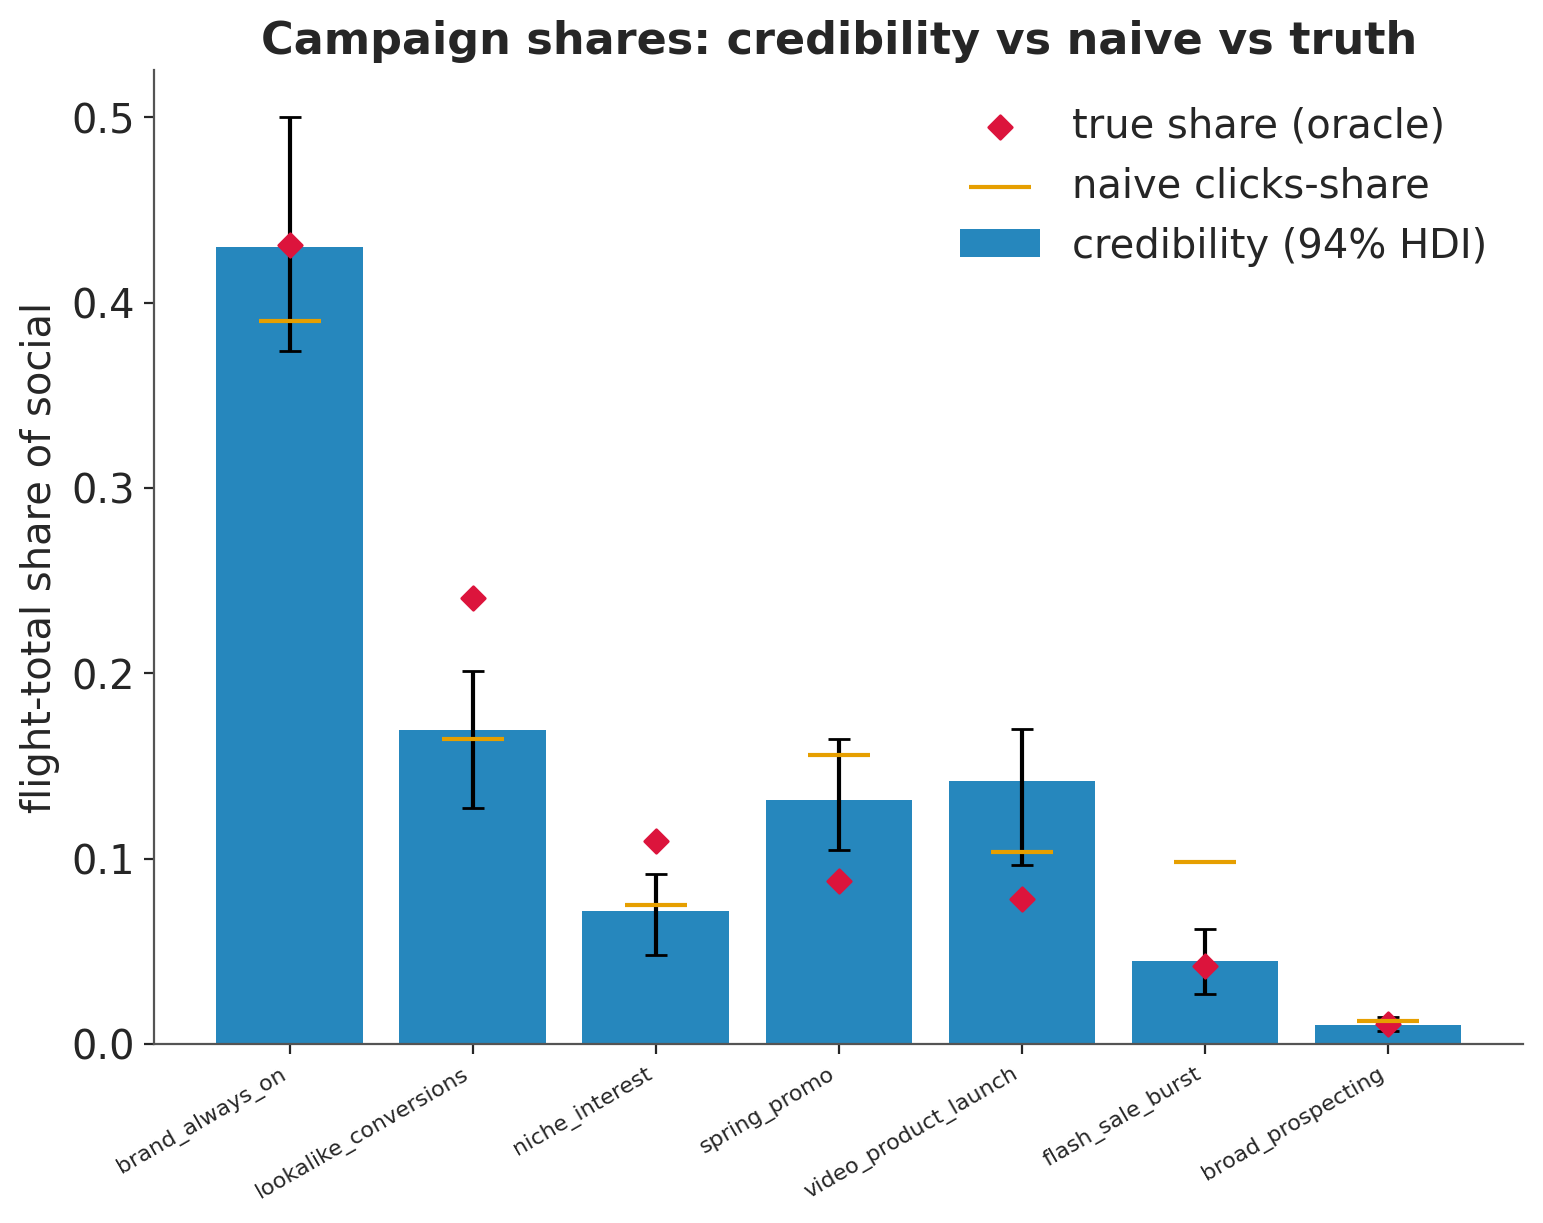

In [14]:
b = res.copy()
xs = np.arange(len(b))
lo = b["credibility_share"].to_numpy() - b["hdi_low"].to_numpy()
hi = b["hdi_high"].to_numpy() - b["credibility_share"].to_numpy()

fig, ax = plt.subplots(layout="constrained")
ax.bar(
    xs,
    b["credibility_share"],
    yerr=[lo, hi],
    capsize=4,
    color="#0072b2",
    alpha=0.85,
    label="credibility (94% HDI)",
)
ax.scatter(
    xs,
    b["true_share"],
    color="crimson",
    marker="D",
    zorder=5,
    label="true share (oracle)",
)
ax.scatter(
    xs,
    b["naive_clicks_share"],
    color="#e69f00",
    marker="_",
    s=500,
    zorder=5,
    label="naive clicks-share",
)
ax.set_xticks(xs)
ax.set_xticklabels(b.index, rotation=30, ha="right", fontsize=8)
ax.set(
    ylabel="flight-total share of social",
    title="Campaign shares: credibility vs naive vs truth",
)
ax.legend();

> **Fig.** Credibility shares (blue, with 94% HDI) vs the naive clicks-split (orange) vs the hidden truth (red diamonds).

And because we carried the uncertainty through, the answer isn't a single number
— it's a full **daily posterior** for every campaign. On top, the daily
credit stacks up to the MMM's social curve by construction — watch the
`broad_prospecting` slice appear from nothing in April. Below it, the
day-by-day story of our reformed superstar `flash_sale_burst`, uncertainty band
and all, against the hidden truth.

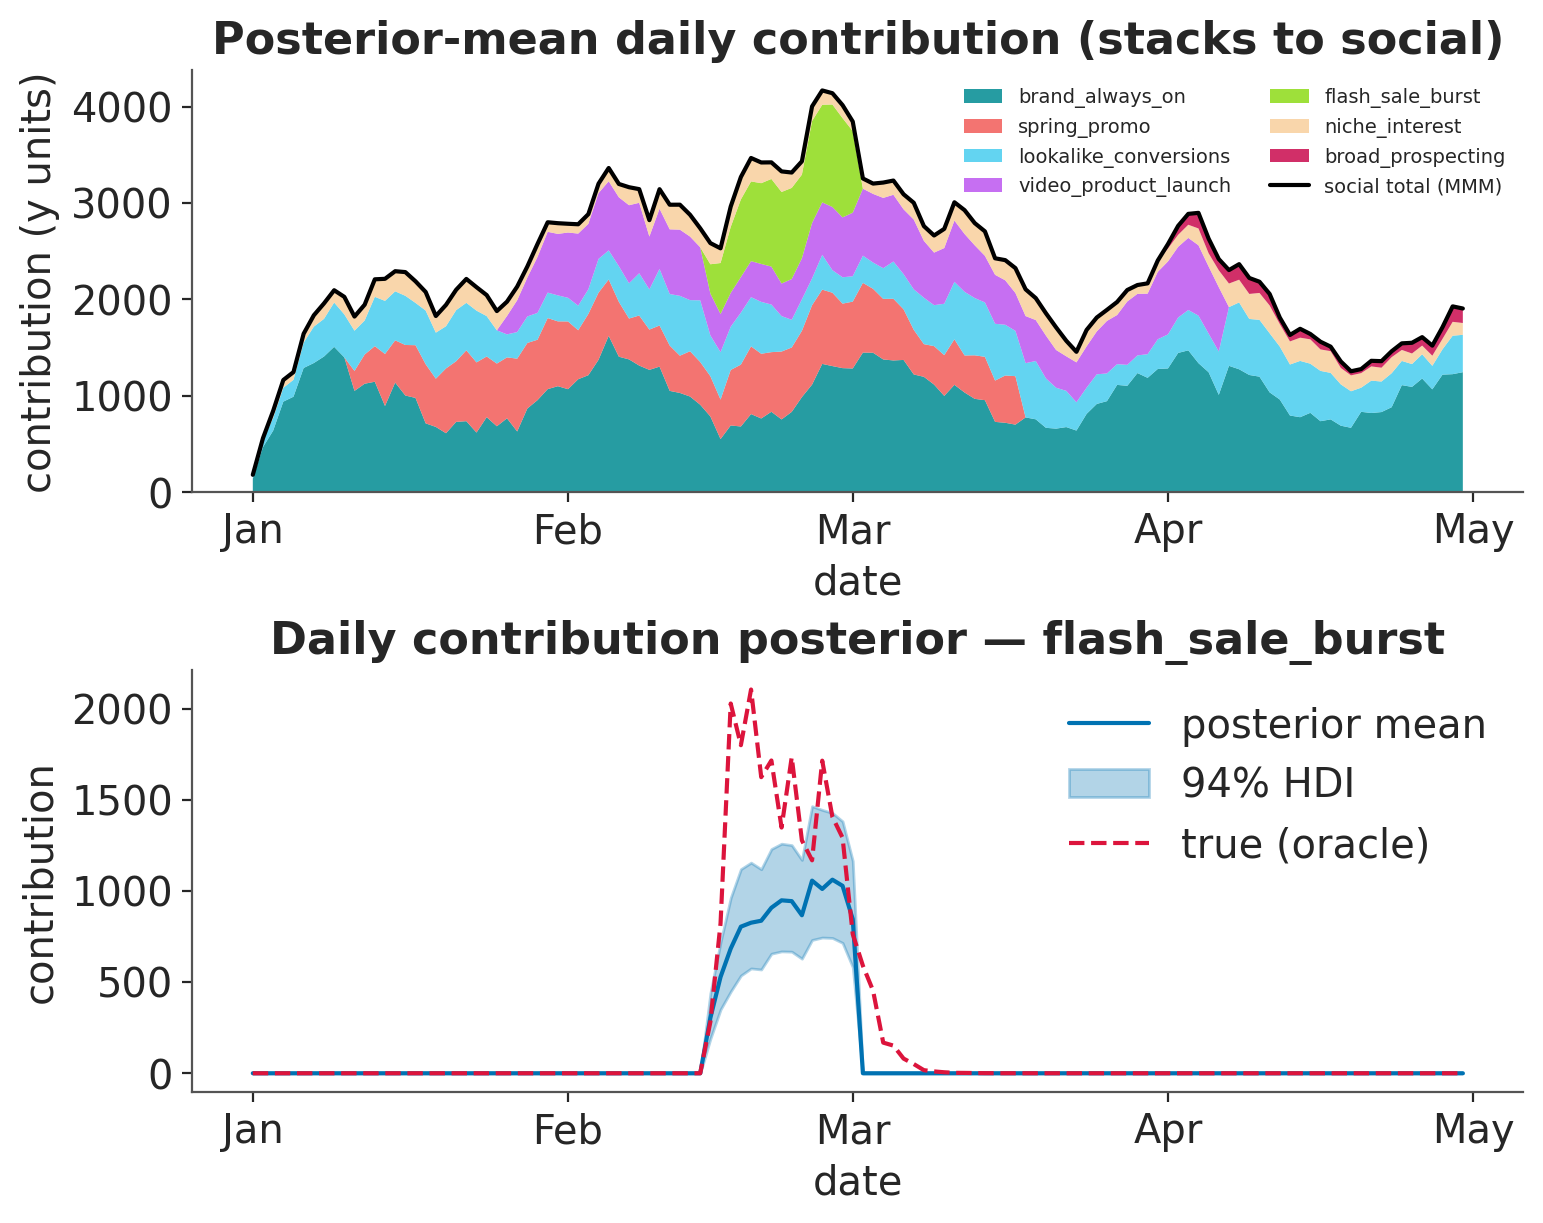

In [15]:
import matplotlib.dates as mdates

daily_mean = contribution.mean("sample")
fig, (ax1, ax2) = plt.subplots(2, 1, layout="constrained")

ax1.stackplot(
    reach_daily.index,
    [daily_mean.sel(campaign=c).to_numpy() for c in CAMPAIGNS],
    labels=CAMPAIGNS,
    alpha=0.85,
)
ax1.plot(
    reach_daily.index, soc_draws.mean(0), color="k", lw=1.5, label="social total (MMM)"
)
ax1.set(
    title="Posterior-mean daily contribution (stacks to social)",
    xlabel="date",
    ylabel="contribution (y units)",
)
ax1.legend(fontsize=7, ncol=2)

cname = "flash_sale_burst"
cd = contribution.sel(campaign=cname)
ch = az.hdi(cd, dim="sample", prob=0.94)
ax2.plot(
    reach_daily.index,
    cd.mean("sample").to_numpy(),
    color="#0072b2",
    label="posterior mean",
)
ax2.fill_between(
    reach_daily.index,
    ch.sel(ci_bound="lower").to_numpy(),
    ch.sel(ci_bound="upper").to_numpy(),
    alpha=0.3,
    color="#0072b2",
    label="94% HDI",
)
ax2.plot(
    truth.index,
    truth[cname].to_numpy(),
    color="crimson",
    ls="--",
    label="true (oracle)",
)
ax2.set(
    title=f"Daily contribution posterior — {cname}",
    xlabel="date",
    ylabel="contribution",
)
ax2.legend()
for _ax in (ax1, ax2):
    _ax.xaxis.set_major_locator(mdates.MonthLocator())
    _ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

> **Fig.** Top: daily credit per campaign, stacking to the MMM social curve. Bottom: the daily posterior for flash_sale_burst vs the truth.

## The honest part

The best thing about this method is also the most grown-up: it knows its own
limits, and it tells you where they are.

::: {.callout-note title="What it's genuinely good at"}
- **It refuses to be fooled by small, loud campaigns.** The less evidence a
  campaign has, the harder its wild self-report is reined in — so bursty,
  novelty-driven campaigns stop hijacking the credit.
- **It never breaks the budget.** The campaign pieces sum back to the MMM's
  channel total *exactly*, every day. It divides the number you trust; it doesn't
  invent a new one.
- **It gives you honest uncertainty**, not false precision — a full posterior per
  campaign, per day.
- **It's built on the safest idea in the toolbox** — partial pooling — so it
  behaves well and is easy to explain to whoever asks.
:::

::: {.callout-warning title="What it cannot do (read before trusting)"}
- **It cures noise, not bias.** It fixes the "small campaigns are jumpy" problem.
  It does **not** fix the fact that clicks aren't incrementality. A campaign that
  genuinely converts far above its delivery volume — here, `niche_interest` — stays
  *under*-credited, because **no method that only sees delivery data can recover
  what delivery data doesn't contain.**
- **On easy data it lands near a simple reach-proportional split.** Much of its
  gain comes from *distrusting clicks*. Its real value-add is principled trust
  weights and calibrated uncertainty, not a dramatic jump in point accuracy.
- **The starting signal is still non-incremental.** Splitting by click share is a
  platform-style guess; credibility disciplines it but inherits its slant.
- **Only seven campaigns.** With so few, the dial's tuning is itself uncertain — a
  fact the Bayesian version at least reports honestly.
:::

::: {.callout-tip title="Run it on your own data — the whole recipe"}
1. **Pull expanding-window reach** per campaign (fix the report's start date,
   extend the end date one day at a time; the day-over-day differences are
   genuinely new people).
2. **Build any naive split** of the MMM channel total from what your dashboard
   already gives you — clicks, conversions, last-touch revenue. It's allowed to
   be bad; that's the point.
3. **Fit the ~15-line model above** and read off each campaign's trust dial
   $Z_c$. Even before the split, Z alone tells you which campaign numbers
   deserve to be taken seriously.
4. **Allocate the MMM channel curve daily** with reach × trust-adjusted-rate
   weights. The pieces sum to the MMM total by construction.
:::

**The bottom line.** This is a well-grounded, uncertainty-aware way to split a
channel's MMM credit across campaigns — most valuable exactly where platform
numbers are least reliable (the small, bursty campaigns). To break through its one
hard limit — that delivery data can't see true incrementality — pair it with a
**lift test**: feed a campaign's measured incremental lift in as a prior, and the
trust dial will do the rest.

In [16]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc,arviz,pytensor,numpy,pandas,matplotlib

Last updated: Thu, 02 Jul 2026

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.15.0

pymc      : 6.0.1
arviz     : 1.2.0
pytensor  : 3.0.7
numpy     : 2.4.6
pandas    : 2.3.3
matplotlib: 3.10.9

IPython    : 9.15.0
arviz      : 1.2.0
arviz_plots: 1.2.0
matplotlib : 3.10.9
numpy      : 2.4.6
pandas     : 2.3.3
pymc       : 6.0.1
scipy      : 1.18.0
xarray     : 2026.4.0

Watermark: 2.6.0

